# Predictive Temperature Model

This notebook contains the complete pipeline for a predictive model on dataset created from the PRE 400 Level Class between 5th March 2026 to 11th Match 2026.

## Sections:
1. Data Reading
2. Data Preparation and Preprocessing
3. Data Visualisation
4. Model Preparation
5. Model Training
6. Model Testing

## 1. Data Reading

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Read the dataset
dataset_path = 'DATA SET - EMERALD_TEMP.csv'
df = pd.read_csv(dataset_path)

print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (1344, 12)


,ID,DAY,TIME_OF DAY,EXACT_TIME(H:M),WEATHER,GRID,CORNER,HEIGHT,NO_OF_PERSONS,WINDOWS_OPEN,HUMIDITY,TEMP_CELCIUS
0,1,1,MORNING,8:35,CLOUDY,A,A1,LOW,2.0,4,0.74,26.0
1,2,1,MORNING,8.35,CLOUDY,A,A1,HIGH,2.0,4,0.76,26.2
2,3,1,MORNING,8:36,CLOUDY,A,A2,LOW,2.0,4,0.70,26.2
3,4,1,MORNING,8:37,CLOUDY,A,A2,HIGH,2.0,4,0.71,26.0
4,5,1,MORNING,8:37,CLOUDY,A,A3,LOW,2.0,4,0.70,25.9


## 2. Data Preparation and Preprocessing

In [8]:
# Drop ID col as it is not a useful feature
df = df.drop('ID', axis=1)

# Handle EXACT_TIME(H:M)
# Convert string times like '8:35' or '8.35' to continuous minutes past midnight
def time_to_minutes(t_str):
    if pd.isna(t_str):
        return np.nan
    t_str = str(t_str).replace('.', ':')
    try:
        h, m = map(int, t_str.split(':'))
        return h * 60 + m
    except:
        return np.nan

df['MINUTES_PAST_MIDNIGHT'] = df['EXACT_TIME(H:M)'].apply(time_to_minutes)
df = df.drop('EXACT_TIME(H:M)', axis=1)

# Handle missing values by dropping rows with NaNs (since we are predicting, we want clean data)
df = df.dropna()
print(f"Dataset shape after dropping missing values: {df.shape}")

# Encode Categorical Variables
categorical_cols = ['TIME_OF DAY', 'WEATHER', 'GRID', 'CORNER', 'HEIGHT']
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("Features available after encoding:")
print(df_encoded.columns.tolist())

Dataset shape after dropping missing values: (1344, 11)
Features available after encoding:
['DAY', 'NO_OF_PERSONS', 'WINDOWS_OPEN', 'HUMIDITY', 'TEMP_CELCIUS', 'MINUTES_PAST_MIDNIGHT', 'TIME_OF DAY_EVENING', 'TIME_OF DAY_MORNING', 'WEATHER_CLOUDY', 'WEATHER_RAINY', 'WEATHER_SUNNY', 'GRID_B', 'GRID_C', 'GRID_D', 'GRID_E', 'GRID_F', 'GRID_G', 'GRID_H', 'CORNER_A2', 'CORNER_A3', 'CORNER_A4', 'CORNER_B1', 'CORNER_B2', 'CORNER_B3', 'CORNER_B4', 'CORNER_C1', 'CORNER_C2', 'CORNER_C3', 'CORNER_C4', 'CORNER_D1', 'CORNER_D2', 'CORNER_D3', 'CORNER_D4', 'CORNER_E1', 'CORNER_E2', 'CORNER_E3', 'CORNER_E4', 'CORNER_F1', 'CORNER_F2', 'CORNER_F3', 'CORNER_F4', 'CORNER_G1', 'CORNER_G2', 'CORNER_G3', 'CORNER_G4', 'CORNER_H1', 'CORNER_H2', 'CORNER_H3', 'CORNER_H4', 'HEIGHT_LOW']


## 3. Data Visualisation

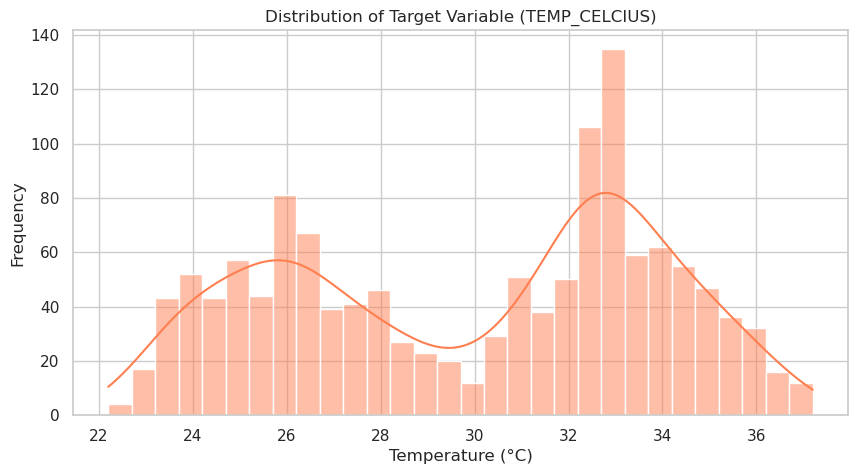

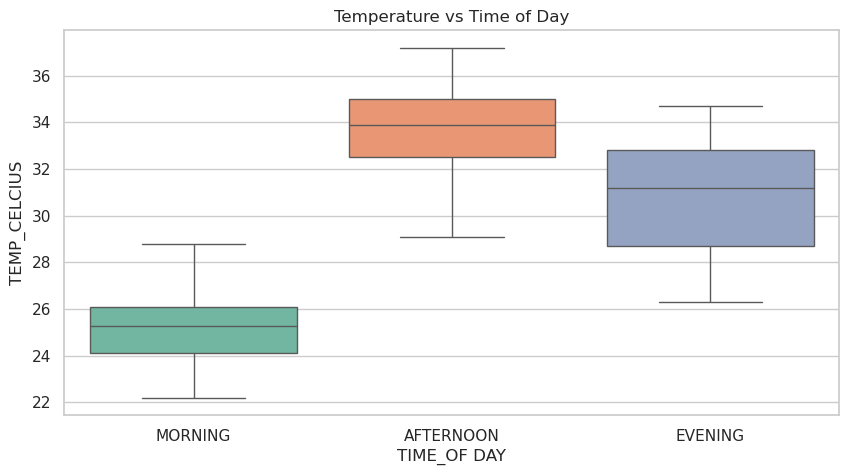

In [9]:
# Set style
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 5))
sns.histplot(df['TEMP_CELCIUS'], kde=True, bins=30, color='coral')
plt.title('Distribution of Target Variable (TEMP_CELCIUS)')
plt.xlabel('Temperature (°C)')
plt.ylabel('Frequency')
plt.show()

plt.figure(figsize=(10, 5))
sns.boxplot(x='TIME_OF DAY', y='TEMP_CELCIUS', data=df, palette='Set2')
plt.title('Temperature vs Time of Day')
plt.show()



## 4. Model Preparation

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separate features and target
X = df_encoded.drop('TEMP_CELCIUS', axis=1)
y = df_encoded['TEMP_CELCIUS']

# Train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale numerical features (important for Neural Networks and distance-based models)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training instances: {X_train.shape[0]}")
print(f"Testing instances: {X_test.shape[0]}")

Training instances: 1075
Testing instances: 269


## 5. Model Training

In [11]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR

# Initialize models
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
svr_model = SVR(kernel='rbf', C=100, gamma='auto', epsilon=0.1)

# Train Random Forest
print("Training Random Forest Regressor...")
rf_model.fit(X_train_scaled, y_train)

# Train Support Vector Regression
print("Training SVR model....")
svr_model.fit(X_train_scaled, y_train)

print("Models trained successfully.")

Training Random Forest Regressor...
Training SVR model....
Models trained successfully.


## 6. Model Testing

--- Random Forest ---
MAE:  0.8564
RMSE: 1.1397
R2:   0.9200

--- SVR ---
MAE:  1.2475
RMSE: 1.5632
R2:   0.8495



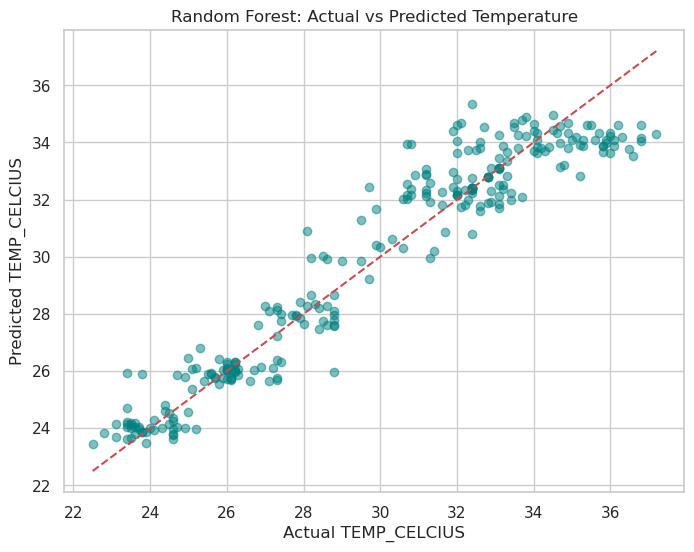

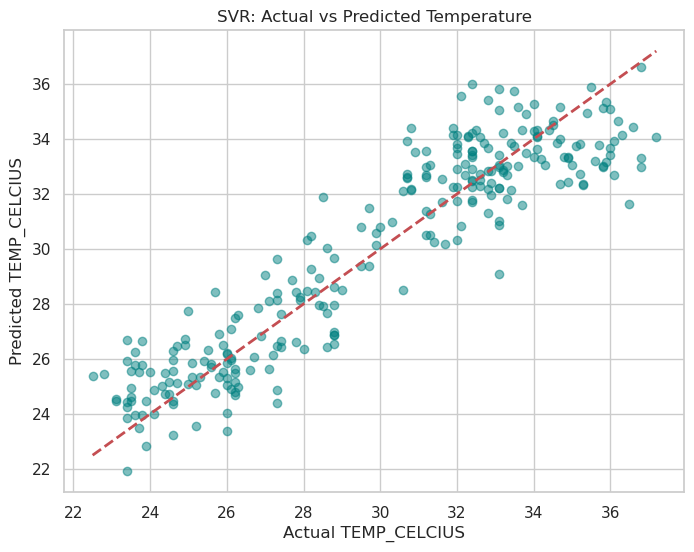

In [12]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Predictions
rf_preds = rf_model.predict(X_test_scaled)
svr_preds = svr_model.predict(X_test_scaled)

def evaluate(model_name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"--- {model_name} ---")
    print(f"MAE:  {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R2:   {r2:.4f}\n")

evaluate("Random Forest", y_test, rf_preds)
evaluate("SVR", y_test, svr_preds)

# Plotting Actual vs Predicted for Random Forest (best visually)
plt.figure(figsize=(8, 6))
plt.scatter(y_test, rf_preds, alpha=0.5, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', )
plt.title('Random Forest: Actual vs Predicted Temperature')
plt.xlabel('Actual TEMP_CELCIUS')
plt.ylabel('Predicted TEMP_CELCIUS')
plt.show()

# Plotting Actual vs Predicted for SVR
plt.figure(figsize=(8, 6))
plt.scatter(y_test, svr_preds, alpha=0.5, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('SVR: Actual vs Predicted Temperature')
plt.xlabel('Actual TEMP_CELCIUS')
plt.ylabel('Predicted TEMP_CELCIUS')
plt.show()